# Held-out NL→FOL faithfulness test set: re-checking rows against their sources

This notebook demonstrates **`data.py`** from the artifact *"Held-out logic translation test set, panel-checked"*.

The artifact is a **meta-evaluation set** for NL→FOL faithfulness metrics. Each row pairs a natural-language
sentence with a **candidate FOL formula**. The candidates are real outputs of 10 LLM slots from 9 families, plus
ccg2lambda and the MALLS GPT-4 gold used as a system. Each row also has a faithfulness label
(`CORRECT / ERROR / CONTESTED / UNRESOLVED / UNPARSEABLE`). The label comes from a z3 solver labeller combined with a
blind, family-disjoint LLM panel. Candidates cover 700 held-out sentences from MALLS-train (strata L25, L20, EXC) and
FOLIO-train (CTRL).

`data.py` is the **last step** of the pipeline. It takes the already labelled groups (`work/assembled.json`) and
**re-verifies every row against the public source it claims to come from**:

* the sentence and original reference must match the MALLS-v0.1-train record, or the FOLIO-v2 premise plus the
  folio-refined formula for CTRL;
* the raw output of an LLM candidate must equal the logged generation record;
* a ccg2lambda candidate must be a real `folio_by_ccg2lambda` logical form;
* the `malls_gpt4_gold` candidate must equal the MALLS gold.

The result is stored per row as `metadata_source_verified` and `metadata_source_file`, and rows are never dropped.
The script then checks the `exp_sel_data_out` schema and writes `full_data_out.json` with mini and preview variants.

**Demo data.** `mini_demo_data.json` contains **every candidate for 7 held-out sentences (93 rows)** from the
`heldout_candidates` group. The sentences span all four strata and all 13 systems. The file also contains the
*minimal subset* of each public source file needed to verify those rows. The original script reads the full source
files from `temp/datasets/`; here the same records come from the loaded JSON.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
This is the original import block of `data.py`, plus `matplotlib` for the final visualization.

In [2]:
from __future__ import annotations

import csv
import json
import re
import shutil
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
from loguru import logger

# notebook-only additions (visualization)
import matplotlib.pyplot as plt

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local file. It has three parts:
`assembled` (the pre-verification rows that `data.py` reads from `work/assembled.json`), `sources` (the public
source records those rows are checked against) and a `description`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({d["dataset"]: len(d["examples"]) for d in data["assembled"]["datasets"]})
print({k: len(v) for k, v in data["sources"].items()})

Demo slice of the held-out NL->FOL faithfulness meta-evaluation set: every candidate for 7 sentences (group heldout_candidates, strata L25/L20/EXC/CTRL), in the pre-verification form data.py reads (work/assembled.json), plus the minimal subset of each public source record needed to re-verify those rows.
{'heldout_candidates': 93}
{'yuan-yang__MALLS-v0__MALLS-v0.1-train.json': 5, 'tasksource__folio/folio_v2_train.jsonl': 5, 'yfxiao__folio-refined__train.csv': 5, 'folio_refined_validation.csv': 0, 'generated_candidates/generations.jsonl': 93, 'kenken6696__folio_by_ccg2lambda/train.parquet:logical_form': 2, 'DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl': 0, 'DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl': 0, 'logiclm_FOLIO_dev_outputs': 3}


## Config
`data.py` has almost no tunable parameters. It is a deterministic check-and-write pass over every row.
* `MAX_EXAMPLES_PER_GROUP` is the number of rows per group to process. `None` means every row in the loaded slice
  (93). The original run processes all 8,507 / 700 / 173 / 1,173 rows of the four groups.
* `GROUP_ORDER` lists the groups that are expected and processed. The original is
  `["heldout_candidates", "heldout_sentences", "panel_calibration", "screen_audit"]`, but the demo slice only
  contains `heldout_candidates`.
* `LIMIT` is the per-file size limit (100 MB). Above it, the output is split into `full_data_out/full_data_out_{i}.json`.
* `ROOT` is the directory the outputs are written to. The original is the script's own directory; here it is
  `demo_out/`.

In [5]:
MAX_EXAMPLES_PER_GROUP = None   # None = all rows of the demo slice (93); original: all rows of all groups
GROUP_ORDER = ["heldout_candidates"]  # original: ["heldout_candidates", "heldout_sentences", "panel_calibration", "screen_audit"]
LIMIT = 100 * 1000 * 1000       # aii-file-size-limit: 100 MB per file (original value)
ROOT = Path("demo_out")         # original: Path(__file__).resolve().parent

## Setup: paths, logging and constants
This is the original module header, with `ROOT` and `GROUP_ORDER`/`LIMIT` now set in the config cell. The `work/`
directory is created because `main()` writes its verification report there. `FORBIDDEN` lists metadata keys the
`exp_sel_data_out` schema does not allow.

In [6]:
ROOT.mkdir(exist_ok=True)
(ROOT / "work").mkdir(exist_ok=True)  # notebook: main() writes work/source_verification.json
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

FORBIDDEN = {"split", "dataset", "context"}


def ws(s: str | None) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Loading the public sources as lookup tables
`load_sources()` turns each public source into a set or dict for fast membership checks. All comparisons use
whitespace-normalised strings (`ws`).

| key | source | used to check |
|---|---|---|
| `malls_train` | MALLS-v0.1 train (NL → gold FOL) | text and reference of L25/L20/EXC rows; the `malls_gpt4_gold` candidate |
| `folio_train_premises` | tasksource FOLIO-v2 train premises | the text of CTRL rows |
| `refined_train_*` | folio-refined train (NL/FOL premise pairs) | the reference of CTRL rows |
| `gens` | the logged LLM generations `(sentence_id, slot, variant) → raw_output` | LLM candidates |
| `ccg_forms` | `folio_by_ccg2lambda` train logical forms | ccg2lambda candidates |
| `curated`, `logiclm_lines`, `refined_val_fols` | DSAVlab-UNIUD curated sets, Logic-LM FOLIO-dev outputs | `screen_audit` and `panel_calibration` rows (empty in this demo) |

**Only change from the original:** each `open(...)`, `read_jsonl(...)` or `pd.read_parquet(...)` of a file under
`temp/datasets/` now reads the same records from `data["sources"]`. The records are shown in comments. The code that
builds the lookup tables is unchanged.

In [7]:
def load_sources() -> dict:
    S = data["sources"]  # notebook: records come from mini_demo_data.json instead of temp/datasets/ files
    src = {}
    src["malls_train"] = {ws(r["NL"]): ws(r["FOL"]) for r in S["yuan-yang__MALLS-v0__MALLS-v0.1-train.json"]}  # json.load(open(L / "yuan-yang__MALLS-v0__MALLS-v0.1-train.json"))
    src["folio_train_premises"] = {ws(p) for r in S["tasksource__folio/folio_v2_train.jsonl"] for p in r["premises"].split("\n")}  # read_jsonl(TD / "tasksource__folio" / "folio_v2_train.jsonl")
    refined, refined_pairs = set(), set()
    for r in S["yfxiao__folio-refined__train.csv"]:  # csv.DictReader(open(L / "yfxiao__folio-refined__train.csv"))
        nls = [s for s in r["nl premises"].split("\n") if s.strip()]
        fols = [s for s in r["fol premises"].split("\n") if s.strip()]
        refined |= {ws(f) for f in fols}
        if len(nls) == len(fols):
            refined_pairs |= {(ws(n), ws(f)) for n, f in zip(nls, fols)}
    src["refined_train_fols"], src["refined_train_pairs"] = refined, refined_pairs
    src["refined_val_fols"] = {ws(f) for r in S["folio_refined_validation.csv"] for f in r["fol premises"].split("\n") if f.strip()}  # csv.DictReader(open(L / "folio_refined_validation.csv"))
    src["gens"] = {(g["sentence_id"], g["slot"], g["prompt_variant"]): g["raw_output"]
                   for g in S["generated_candidates/generations.jsonl"] if g.get("raw_output") is not None}  # read_jsonl(TD / "generated_candidates" / "generations.jsonl")
    df = pd.DataFrame({"logical_form": S["kenken6696__folio_by_ccg2lambda/train.parquet:logical_form"]})  # pd.read_parquet(TD / "kenken6696__folio_by_ccg2lambda" / "data" / "train-00000-of-00001.parquet")
    src["ccg_forms"] = {ws(x) for x in df["logical_form"]}
    cur = {}
    for f, newk in [("DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl", "FOL_sentence"),
                    ("DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl", "FOL_sentence_new")]:
        for r in S[f]:  # read_jsonl(L / f)
            cur[str(r["id"])] = (ws(r["NL_sentence"]), ws(r["FOL_sentence_old"]), ws(r[newk]), f)
    src["curated"] = cur
    src["curated_corrected_fols"] = {v[2] for v in cur.values()}
    lines = set()
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in S["logiclm_FOLIO_dev_outputs"][m]:  # json.load(open(TD / "logiclm_FOLIO_dev_outputs" / f"FOLIO_dev_{m}.json"))
            prog = r["raw_logic_programs"][0] if isinstance(r["raw_logic_programs"], list) else r["raw_logic_programs"]
            for line in prog.splitlines():
                if ":::" in line:
                    fol, nl = line.strip().split(":::", 1)
                    lines.add((m, ws(fol), ws(nl)))
    src["logiclm_lines"] = lines
    return src

## Per-row provenance checks
Each function returns `(verified: bool, source_file: str)` for one row. The code is unchanged from `data.py`.

* **`verify_heldout`** handles held-out candidates and sentences.
  * For **CTRL**, the text must be a FOLIO-v2 train premise and the reference must be the matching folio-refined
    formula.
  * For **MALLS strata**, the text must be a MALLS-train sentence and the reference must equal its gold. The
    exception is a reference the panel repaired (`PANEL_REPAIRED`).
  * The candidate is then checked by system: `malls_gpt4_gold` must equal the MALLS gold, `ccg2lambda` must be a
    real ccg2lambda logical form, and an LLM candidate's raw output must equal the logged generation for
    `(sentence_id, slot, prompt_variant)`.
* **`verify_screen`** and **`verify_calib`** do the same for the `screen_audit` and `panel_calibration` groups. They
  are not run in this demo because those groups are not in the slice.

In [8]:
def verify_heldout(ex: dict, src: dict, sentence_row: bool = False) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    text = ws(inp["text"])
    stratum = ex["metadata_strata"]["source_stratum"]
    orig_ref = ws(ex.get("metadata_original_reference_fol") or inp["reference_fol"]) if sentence_row else None
    if stratum == "CTRL":
        ref = ws(inp["reference_fol"])
        ok = text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"])
        file = "tasksource__folio/folio_v2_train.jsonl + local_sources/yfxiao__folio-refined__train.csv"
    else:
        gold = src["malls_train"].get(text)
        ref = orig_ref if sentence_row else ws(inp["reference_fol"])
        ok = gold is not None and (ref == gold or ex.get("metadata_reference_status") == "PANEL_REPAIRED")
        file = "local_sources/yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
    if sentence_row or not ok:
        return ok, file
    sys_ = ex["metadata_system"]
    if sys_ == "malls_gpt4_gold":
        return ws(inp["candidate_fol"]) == src["malls_train"].get(text), file
    if sys_ == "ccg2lambda":
        return ws(ex["metadata_raw_output"]) in src["ccg_forms"], file + " + kenken6696__folio_by_ccg2lambda/train"
    raw = src["gens"].get((ex["metadata_sentence_id"], ex["metadata_slot"], ex["metadata_prompt_variant"]))
    return raw is not None and raw == ex["metadata_raw_output"], file + " + generated_candidates/generations.jsonl"


def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_track"] == "H":
        c = src["curated"].get(str(ex["metadata_record_id"]))
        ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["candidate_fol"]) and c[2] == ws(inp["reference_fol"])
        return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"
    ok_line = (ex["metadata_system"], ws(inp["candidate_fol"]), ws(inp["text"])) in src["logiclm_lines"]
    ref = ws(inp["reference_fol"])
    ok_ref = ref in src["curated_corrected_fols"] or ref in src["refined_val_fols"]
    return ok_line and ok_ref, f"logiclm_FOLIO_dev_outputs/FOLIO_dev_{ex['metadata_system']}.json"


def verify_calib(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_subset"] == "synthetic_gate":
        text, ref = ws(inp["text"]), ws(inp["reference_fol"])
        return text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"]), \
            "local_sources/yfxiao__folio-refined__train.csv"
    c = src["curated"].get(str(ex["metadata_record_id"]))
    ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["original_fol"]) and c[2] == ws(inp["corrected_fol"])
    return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"

## Schema check and output writers
The code is unchanged from `data.py`.
* `check_schema` enforces the `exp_sel_data_out` format: a list of `{dataset, examples}` groups, where each example
  has string `input`/`output` and only `metadata_*` extra keys.
* `trunc` and `mini` build the preview variant (long strings truncated) and the mini variant (3 examples per group).
* `write_parts` splits the output into ≤`LIMIT`-byte part files. It is only used when the single file would exceed
  100 MB, which the demo never does.

In [9]:
def check_schema(obj: dict) -> None:
    assert isinstance(obj.get("datasets"), list) and obj["datasets"]
    for d in obj["datasets"]:
        assert set(d) == {"dataset", "examples"} and d["examples"], d.get("dataset")
        for ex in d["examples"]:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str)
            for k in ex:
                assert k in ("input", "output") or (k.startswith("metadata_") and re.fullmatch(r"metadata_[a-zA-Z_][a-zA-Z0-9_]*", k)), k
                assert k not in FORBIDDEN


def trunc(x, n=200):
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(v, n) for v in x]
    if isinstance(x, dict):
        return {k: trunc(v, n) for k, v in x.items()}
    return x


def mini(obj, k=3):
    return {"metadata": obj.get("metadata", {}), "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:k]} for d in obj["datasets"]]}


def write_parts(obj: dict) -> list[Path]:
    out = ROOT / "full_data_out"
    if out.exists():
        shutil.rmtree(out)
    out.mkdir()
    parts, cur, size = [], [], 0
    for d in obj["datasets"]:
        chunk = []
        for ex in d["examples"]:
            sz = len(json.dumps(ex, ensure_ascii=False).encode())
            if size + sz > LIMIT and (cur or chunk):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur); cur, chunk, size = [], [], 0
            chunk.append(ex); size += sz
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    paths = []
    for i, p in enumerate(parts, 1):
        o = {"metadata": {**obj["metadata"], "part": i, "n_parts": len(parts)}, "datasets": p}
        check_schema(o)
        f = out / f"full_data_out_{i}.json"
        f.write_text(json.dumps(o, ensure_ascii=False))
        (out / f"mini_full_data_out_{i}.json").write_text(json.dumps(mini(o), ensure_ascii=False, indent=1))
        (out / f"preview_full_data_out_{i}.json").write_text(json.dumps(trunc(mini(o)), ensure_ascii=False, indent=1))
        paths.append(f)
    m = mini(obj)
    (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
    return paths

## `main()`: verify every row, attach provenance, write `full_data_out.json`
The steps match `data.py`:
1. load the assembled groups and check that they are in the expected order;
2. build the source lookups;
3. for each group, run its verifier on every row and store `metadata_source_verified` / `metadata_source_file`,
   then log a per-group report of rows, verified/unverified counts and the label distribution;
4. check the schema and write one file, or split it into parts above 100 MB;
5. save the report to `work/source_verification.json`.

**Notebook changes, kept minimal:**
* `A` comes from `data["assembled"]` rather than `work/assembled.json`, optionally capped at `MAX_EXAMPLES_PER_GROUP`.
* The per-group loop skips groups that are not in the loaded slice (`if name in groups`).

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    A = data["assembled"]  # notebook: was json.loads((ROOT / "work" / "assembled.json").read_text(encoding="utf-8"))
    groups = {d["dataset"]: d["examples"][:MAX_EXAMPLES_PER_GROUP] for d in A["datasets"]}  # notebook: optional cap
    assert list(groups) == GROUP_ORDER, list(groups)
    src = load_sources()
    logger.info(f"sources loaded: MALLS-train {len(src['malls_train'])}, generations {len(src['gens'])}, Logic-LM lines {len(src['logiclm_lines'])}")
    report = {}
    for name, fn in [("heldout_candidates", lambda e: verify_heldout(e, src)),
                     ("heldout_sentences", lambda e: verify_heldout(e, src, sentence_row=True)),
                     ("panel_calibration", lambda e: verify_calib(e, src)),
                     ("screen_audit", lambda e: verify_screen(e, src))]:
        if name not in groups:  # notebook: the demo slice holds only some groups
            continue
        c = Counter()
        for ex in groups[name]:
            ok, f = fn(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        report[name] = {"rows": len(groups[name]), "verified": c[True], "unverified": c[False],
                        "labels": dict(Counter(e["output"] for e in groups[name]))}
        logger.info(f"{name}: {report[name]}")
    obj = {"metadata": {**A["metadata"], "source_verification": report,
                        "reading": "for f in sorted(glob('full_data_out/full_data_out_*.json')): concatenate each group's examples"},
           "datasets": [{"dataset": g, "examples": groups[g]} for g in GROUP_ORDER]}
    check_schema(obj)
    blob = json.dumps(obj, ensure_ascii=False)
    if len(blob.encode()) <= LIMIT:
        if (ROOT / "full_data_out").exists():
            shutil.rmtree(ROOT / "full_data_out")
        (ROOT / "full_data_out.json").write_text(blob)
        m = mini(obj)
        (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
        (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
        paths = [ROOT / "full_data_out.json"]
    else:
        (ROOT / "full_data_out.json").unlink(missing_ok=True)
        paths = write_parts(obj)
    for p in paths:
        logger.info(f"{p.relative_to(ROOT)} {p.stat().st_size / 1e6:.2f} MB")
    (ROOT / "work" / "source_verification.json").write_text(json.dumps(report, indent=1))

In [11]:
main()

18:01:47|INFO   |sources loaded: MALLS-train 5, generations 86, Logic-LM lines 0


18:01:47|INFO   |heldout_candidates: {'rows': 93, 'verified': 93, 'unverified': 0, 'labels': {'CONTESTED': 17, 'ERROR': 35, 'CORRECT': 26, 'UNPARSEABLE': 11, 'UNRESOLVED': 4}}


18:01:47|INFO   |full_data_out.json 0.26 MB


## Results
The next cell reads back the file that `main()` wrote (`demo_out/full_data_out.json`) and shows:
1. the source-verification report;
2. one sentence with **all its candidates**, which shows how the systems differ and how labels and tiers are
   assigned;
3. label distributions by stratum and by system;
4. the rows that count for the **primary analysis**: tiers A+B, excluding `CONTESTED` and `reading_choice`.

Keep the dataset's caveats in mind. The panel is strict: it rejected 82% of MALLS gold, so `ERROR` is over-called.
Confirm results on tier A (solver-decided) as well. This is a held-out set, so do not tune thresholds on it.

Source verification report:


                   rows verified unverified                                                                             labels
heldout_candidates   93       93          0  {'CONTESTED': 17, 'ERROR': 35, 'CORRECT': 26, 'UNPARSEABLE': 11, 'UNRESOLVED': 4}

Sentence: An asteroid is a small rocky body orbiting the sun, a comet is a celestial object consisting of a nucleus of ice and dust and orbiting the sun, and a meteor is a small celestial body that burns upon entering Earth's atmosphere.
Reference FOL: ∀x (Asteroid(x) ↔ (SmallRockyBody(x) ∧ Orbits(x, sun))) ∧ ∀x (Comet(x) ↔ (CelestialObject(x) ∧ ConsistsOf(x, nucleusOfIceAndDust) ∧ Orbits(x, sun))) ∧ ∀x (Meteor(x) ↔ (SmallCelestialBody(x) ∧ BurnsUponEntering(x, earthsAtmosphere))) | reference status: PANEL_REPAIRED
                        system     variant       label tier                                                                                                                                                                     

label    CONTESTED  CORRECT  ERROR  UNPARSEABLE  UNRESOLVED  All
stratum                                                         
CTRL             8       10      4            2           3   27
EXC              5        7      9            5           1   27
L20              1        2      9            1           0   13
L25              3        7     13            3           0   26
All             17       26     35           11           4   93

Labels by system:
label                           CONTESTED  CORRECT  ERROR  UNPARSEABLE  UNRESOLVED  All
system                                                                                 
ccg2lambda                              0        0      1            1           0    2
command-r7b-12-2024                     0        1      5            1           0    7
deepseek-v3.2                           1        4      2            0           0    7
gemini-2.5-flash                        2        3      1            1           0    

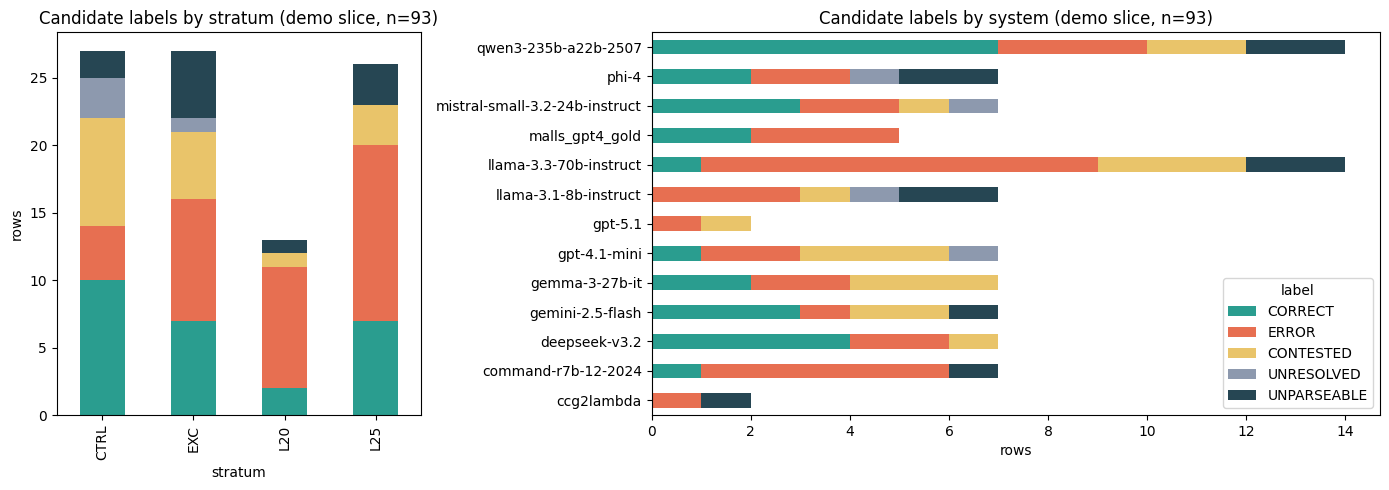

In [12]:
out = json.loads((ROOT / "full_data_out.json").read_text())
rows = [ex for d in out["datasets"] for ex in d["examples"]]
print("Source verification report:")
print(pd.DataFrame(out["metadata"]["source_verification"]).T.to_string())

df = pd.DataFrame([{
    "sentence_id": ex["metadata_sentence_id"],
    "stratum": ex["metadata_strata"]["source_stratum"],
    "words": ex["metadata_strata"]["words"],
    "n_cond": ex["metadata_strata"]["n_conditions"],
    "system": ex["metadata_system"].split(":")[-1].split("/")[-1],
    "variant": ex["metadata_prompt_variant"],
    "candidate_fol": json.loads(ex["input"])["candidate_fol"],
    "label": ex["output"],
    "tier": ex["metadata_label_tier"],
    "reading_choice": ex["metadata_reading_choice"],
    "verified": ex["metadata_source_verified"],
} for ex in rows])

# --- one sentence, all candidates ---
sid = df[df.stratum == "L25"].sentence_id.iloc[0]
ex0 = next(ex for ex in rows if ex["metadata_sentence_id"] == sid)
inp0 = json.loads(ex0["input"])
print("\nSentence:", inp0["text"])
print("Reference FOL:", inp0["reference_fol"], "| reference status:", ex0["metadata_reference_status"])
with pd.option_context("display.max_colwidth", 90, "display.width", 250):
    print(df[df.sentence_id == sid][["system", "variant", "label", "tier", "candidate_fol"]].to_string(index=False))

# --- label counts by stratum / system ---
print("\nLabels by stratum:")
print(pd.crosstab(df.stratum, df.label, margins=True).to_string())
print("\nLabels by system:")
print(pd.crosstab(df.system, df.label, margins=True).to_string())

prim = df[df.tier.isin(["A", "B"]) & (df.label != "CONTESTED") & (~df.reading_choice)]
print(f"\nPrimary-analysis rows (tier A+B, not CONTESTED, not reading_choice): {len(prim)} / {len(df)}")
print(pd.crosstab(prim.stratum, [prim.tier, prim.label]).to_string())

LABELS = ["CORRECT", "ERROR", "CONTESTED", "UNRESOLVED", "UNPARSEABLE"]
COLORS = {"CORRECT": "#2a9d8f", "ERROR": "#e76f51", "CONTESTED": "#e9c46a", "UNRESOLVED": "#8d99ae", "UNPARSEABLE": "#264653"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})
for ax, key in zip(axes, ["stratum", "system"]):
    ct = pd.crosstab(df[key], df.label).reindex(columns=LABELS, fill_value=0)
    ct.plot(kind="barh" if key == "system" else "bar", stacked=True, ax=ax, color=[COLORS[l] for l in LABELS], legend=False)
    ax.set_title(f"Candidate labels by {key} (demo slice, n={len(df)})")
    ax.set_xlabel("rows" if key == "system" else key); ax.set_ylabel("" if key == "system" else "rows")
axes[1].legend(title="label", loc="lower right")
plt.tight_layout(); plt.show()